# STEP 0: INSTALLATION AND IMPORTS
TEA_RNN_Model.ipynb

This script trains a simple Recurrent Neural Network (RNN) for multi-label text emotion analysis.
It is designed to be a legacy model for comparison against a Transformer-based model like IndoBERT.

Key features aligned for fair comparison:
- BPE (Byte-Pair Encoding) tokenizer trained from scratch on the dataset.
- Input sequence length fixed at 128.
- Embedding dimension set to 768.
- The same stratified data splitting and evaluation metrics are used.

In [1]:
# Ensure necessary libraries are installed.
!pip install pandas scikit-learn scikit-multilearn emoji tensorflow "tokenizers==0.15.2" wandb --quiet

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

# Scikit-learn for data splitting and metrics
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Hugging Face Tokenizers for BPE
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# TensorFlow / Keras for model building
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


# STEP 1: LOAD PRE-SPLIT DATASETS

In [3]:
print("\n--- STEP 1: LOADING PRE-SPLIT DATASETS ---")
try:
    df_train = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/main/train_dataset.csv')
    df_val = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/main/validation_dataset.csv')
    df_test = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/main/test_dataset.csv')

    # Handle potential empty text rows that might have been saved
    df_train.dropna(subset=['text'], inplace=True)
    df_val.dropna(subset=['text'], inplace=True)
    df_test.dropna(subset=['text'], inplace=True)

    print("Pre-split datasets loaded successfully.")
    print(f"Training set size: {len(df_train)}")
    print(f"Validation set size: {len(df_val)}")
    print(f"Test set size: {len(df_test)}")

except FileNotFoundError:
    print(f"Error: Pre-split data not found.")
    exit()

# Define label columns
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
print(f"Labels for classification: {label_columns}")

# Prepare labels for training
y_train = df_train[label_columns].to_numpy()
y_val = df_val[label_columns].to_numpy()
y_test = df_test[label_columns].to_numpy()


--- STEP 1: LOADING PRE-SPLIT DATASETS ---
Pre-split datasets loaded successfully.
Training set size: 89324
Validation set size: 22078
Test set size: 28012
Labels for classification: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']


# STEP 2: BPE TOKENIZATION

In [4]:
print("\n--- STEP 2: BPE TOKENIZATION ---")

# Constants aligned with IndoBERT model
MAX_LENGTH = 128
VOCAB_SIZE = 30000
ARTIFACTS_DIR = 'rnn_model_artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 1. Initialize and Train the Tokenizer
bpe_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(vocab_size=VOCAB_SIZE, special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]"])

# Train the tokenizer ONLY on the training data
bpe_tokenizer.train_from_iterator(df_train['text'], trainer)
print(f"BPE tokenizer trained with a vocabulary size of {bpe_tokenizer.get_vocab_size()}.")

# 2. Configure Padding
pad_id = bpe_tokenizer.token_to_id("[PAD]")
bpe_tokenizer.enable_padding(direction='right', pad_id=pad_id, pad_token="[PAD]", length=MAX_LENGTH)
print(f"Padding enabled to max length: {MAX_LENGTH}")

# 3. Encode the datasets
def encode_texts(tokenizer, texts):
    """Encodes a list of texts into padded integer sequences."""
    output = tokenizer.encode_batch(texts)
    return np.array([enc.ids for enc in output])

X_train_encoded = encode_texts(bpe_tokenizer, df_train['text'].tolist())
X_val_encoded = encode_texts(bpe_tokenizer, df_val['text'].tolist())
X_test_encoded = encode_texts(bpe_tokenizer, df_test['text'].tolist())

print("Datasets successfully encoded.")
print(f"Shape of encoded training data: {X_train_encoded.shape}")


--- STEP 2: BPE TOKENIZATION ---
BPE tokenizer trained with a vocabulary size of 30000.
Padding enabled to max length: 128
Datasets successfully encoded.
Shape of encoded training data: (89324, 128)


# STEP 3: MODEL ARCHITECTURE DEFINITION

In [5]:


# Define hyperparameters in a dictionary for easy logging
hyperparameters = {
    "embedding_dim": 768,
    "rnn_units": 128,
    "learning_rate": 0.001, # Default Adam LR
    "epochs": 15,
    "batch_size": 32,
    "vocab_size": bpe_tokenizer.get_vocab_size(),
    "max_length": MAX_LENGTH,
    "architecture": "SimpleRNN"
}

# WANDB integration for experiment tracking.

try:
    from google.colab import userdata
    wandb_api_key = userdata.get('WANDB_API')
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
        print("WANDB login successful.")

    else:
        print("WANDB_API_KEY not found in Colab secrets. Please login manually.")
        wandb.login()

except (ImportError, KeyError):
    print("Not in Colab or WANDB key not set. Assuming local environment.")
    wandb.login()

# Initialize a new W&B run

wandb.init(
    project="tea_RNN_model",
    name="rnn_run_1",
    config=hyperparameters
)

print("\n--- STEP 3: DEFINING SIMPLE RNN MODEL ARCHITECTURE ---")

EMBEDDING_DIM = 768 # Aligned with IndoBERT's hidden dimension
NUM_LABELS = len(label_columns)

model = Sequential([
    # Embedding Layer: Turns integer sequences into dense vectors.
    Embedding(
        input_dim=hyperparameters['vocab_size'],
        output_dim=hyperparameters['embedding_dim'],
        input_length=hyperparameters['max_length'],
        mask_zero=True  # Masking for padded values
    ),
    # Simple RNN Layer: The core recurrent layer.
    SimpleRNN(hyperparameters['rnn_units'],return_sequences=False), # return_sequences=False as we need one output for the whole sequence
    # Output Layer: Produces a probability for each of the 8 emotions.
    Dense(NUM_LABELS, activation='sigmoid') # Sigmoid for multi-label classification
])

model.summary()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: farhanprwnto (farhanprwnto-universitas-sumatera-utara) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WANDB login successful.



--- STEP 3: DEFINING SIMPLE RNN MODEL ARCHITECTURE ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# STEP 4: MODEL COMPILATION

In [6]:
print("\n--- STEP 4: COMPILING THE MODEL ---")
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Standard loss for multi-label problems
    metrics=[
        F1Score(average='macro', threshold=0.5, name='f1_macro'),
        F1Score(average='micro', threshold=0.5, name='f1_micro')
    ]
)
print("Model compiled successfully.")


--- STEP 4: COMPILING THE MODEL ---
Model compiled successfully.


# STEP 5: MODEL TRAINING

In [7]:
print("\n--- STEP 5: TRAINING THE MODEL ---")
BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, 'best_rnn_model.keras')

# Define callbacks using the modern W&B integration.
# WandbMetricsLogger will log all metrics and loss.
# WandbModelCheckpoint will save the best model locally and log it as a W&B Artifact.

callbacks_list = [
    WandbMetricsLogger(),
    WandbModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_f1_macro',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]


history = model.fit(
    X_train_encoded, y_train,
    batch_size=hyperparameters['batch_size'],
    epochs=hyperparameters['epochs'],
    validation_data=(X_val_encoded, y_val),
    callbacks=callbacks_list
)

print("Model training complete.")

wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.



--- STEP 5: TRAINING THE MODEL ---
Epoch 1/15
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - f1_macro: 0.3219 - f1_micro: 0.6230 - loss: 0.3698
Epoch 1: val_f1_macro improved from -inf to 0.40986, saving model to rnn_model_artifacts/best_rnn_model.keras
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 70s 23ms/step - f1_macro: 0.3219 - f1_micro: 0.6231 - loss: 0.3697 - val_f1_macro: 0.4099 - val_f1_micro: 0.7203 - val_loss: 0.3113
Epoch 2/15
2790/2792 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - f1_macro: 0.4477 - f1_micro: 0.7233 - loss: 0.2906
Epoch 2: val_f1_macro improved from 0.40986 to 0.46511, saving model to rnn_model_artifacts/best_rnn_model.keras
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 62s 22ms/step - f1_macro: 0.4478 - f1_micro: 0.7233 - loss: 0.2906 - val_f1_macro: 0.4651 - val_f1_micro: 0.7057 - val_loss: 0.2987
Epoch 3/15
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_macro: 0.5870 - f1_micro: 0.7893 - loss: 0.2317
Epoch 3: val_f1_macro did not improve from 0.46511
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/

# STEP 6: FINAL EVALUATION


--- STEP 6: FINAL EVALUATION ON TEST SET ---
Loading best model from: rnn_model_artifacts/best_rnn_model.keras
876/876 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

Final Performance Metrics:
f1_macro: 0.5102
f1_micro: 0.7161
precision_micro: 0.7142
recall_micro: 0.7181
accuracy_exact_match: 0.3924

Final metrics saved to rnn_model_artifacts/final_performance_metrics.json

Generating and saving training history plot...
Training history plot saved to rnn_model_artifacts/training_history.png


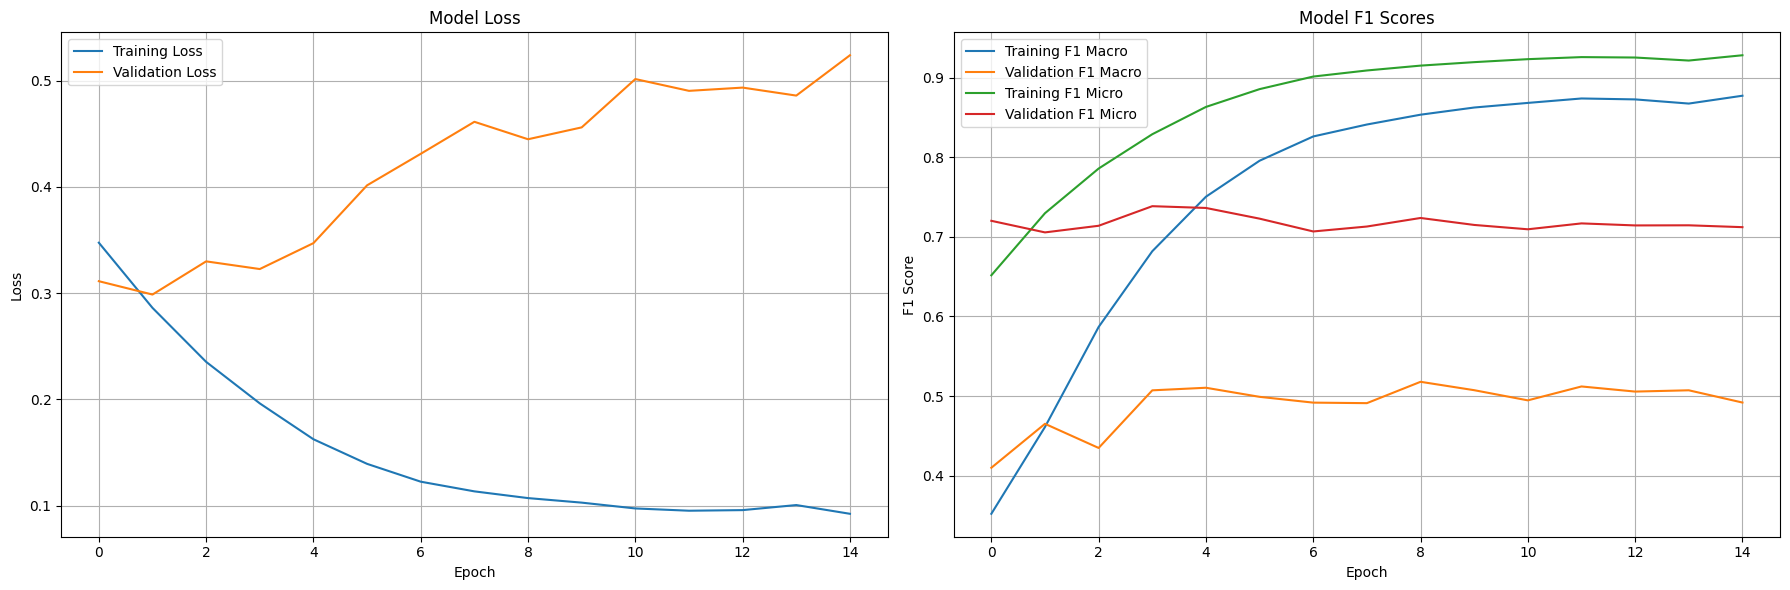


Generating confusion matrices for each label...
Confusion matrices plot saved to rnn_model_artifacts/confusion_matrices_rnn.png


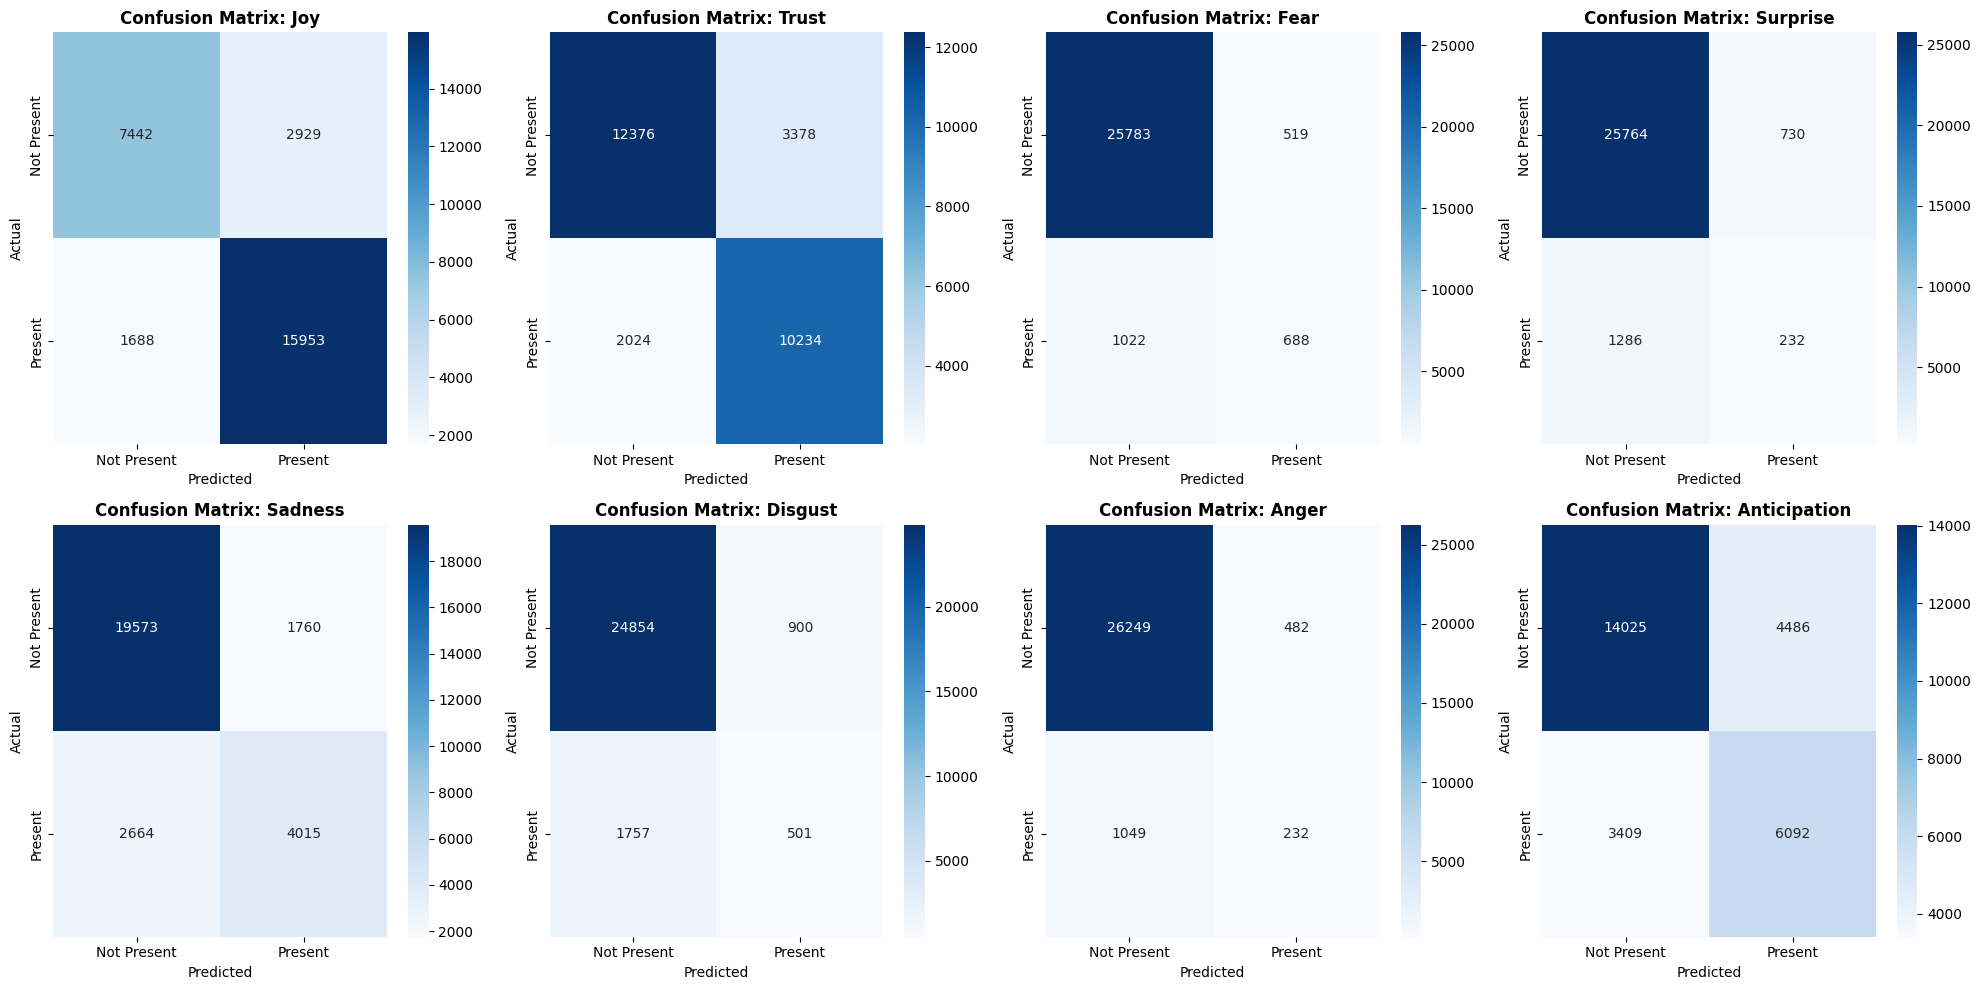

In [8]:
print("\n--- STEP 6: FINAL EVALUATION ON TEST SET ---")
# Explicitly load the best model saved during training for a fair evaluation.
print(f"Loading best model from: {BEST_MODEL_PATH}")
best_model = load_model(
    BEST_MODEL_PATH,
    custom_objects={'F1Score': F1Score} # Required for custom metrics
)

# Make predictions with the best model
y_pred_proba = best_model.predict(X_test_encoded)
# Apply 0.5 threshold to get binary predictions
y_pred = (y_pred_proba > 0.5).astype(int)

def calculate_metrics(y_true, y_pred):
    """Calculates and returns a dictionary of performance metrics."""
    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'accuracy_exact_match': accuracy_score(y_true, y_pred)
    }
    return metrics

final_metrics = calculate_metrics(y_test, y_pred)
print("\nFinal Performance Metrics:")
for name, value in final_metrics.items():
    print(f"{name}: {value:.4f}")

# Log final metrics to W&B
wandb.log({"final_test_metrics": final_metrics})

# Save final metrics to a JSON file
metrics_path = os.path.join(ARTIFACTS_DIR, 'final_performance_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=4)
print(f"\nFinal metrics saved to {metrics_path}")

# Visualize and Save Training History
print("\nGenerating and saving training history plot...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot Loss
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot F1 Scores
ax2.plot(history.history['f1_macro'], label='Training F1 Macro')
ax2.plot(history.history['val_f1_macro'], label='Validation F1 Macro')
ax2.plot(history.history['f1_micro'], label='Training F1 Micro')
ax2.plot(history.history['val_f1_micro'], label='Validation F1 Micro')
ax2.set_title('Model F1 Scores')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
history_fig_path = os.path.join(ARTIFACTS_DIR, 'training_history.png')
plt.savefig(history_fig_path)
print(f"Training history plot saved to {history_fig_path}")
plt.show()

# Log the training history plot to W&B
wandb.log({"training_history": wandb.Image(history_fig_path)})

# Visualize Confusion Matrices
print("\nGenerating confusion matrices for each label...")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, label_name in enumerate(label_columns):
    cm = confusion_matrix(y_true=y_test[:, i], y_pred=y_pred[:, i])
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Present', 'Present'], yticklabels=['Not Present', 'Present'])
    ax.set_title(f"Confusion Matrix: {label_name.title()}", fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()

# Save the figure to a file
figure_path = os.path.join(ARTIFACTS_DIR, 'confusion_matrices_rnn.png')
plt.savefig(figure_path)
print(f"Confusion matrices plot saved to {figure_path}")

plt.show()

# Log the confusion matrix plot to W&B
wandb.log({"confusion_matrices": wandb.Image(figure_path)})

# STEP 7: SAVE FINAL ARTIFACTS

In [9]:
print("\n--- STEP 7: SAVING FINAL ARTIFACTS ---")

# The best model, metrics, and plots are already saved.
# We just need to save the tokenizer and metadata.

# 1. Save BPE Tokenizer
tokenizer_path = os.path.join(ARTIFACTS_DIR, "bpe_tokenizer_rnn.json")
bpe_tokenizer.save(tokenizer_path)
print(f"BPE Tokenizer saved to {tokenizer_path}")

# 2. Save model metadata (labels and max_length)

model_metadata = {
    "label_columns": label_columns,
    "max_length": MAX_LENGTH,
    "hyperparameters": hyperparameters
}
metadata_path = os.path.join(ARTIFACTS_DIR, "model_metadata_rnn.json")
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)
print(f"Model metadata saved to {metadata_path}")

print("\nScript finished.")




--- STEP 7: SAVING FINAL ARTIFACTS ---
BPE Tokenizer saved to rnn_model_artifacts/bpe_tokenizer_rnn.json
Model metadata saved to rnn_model_artifacts/model_metadata_rnn.json

Script finished.


In [ ]:
print("\n--- STEP 8: SAVING ARTIFACTS TO GOOGLE DRIVE ---")

from google.colab import drive
import shutil

# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")
    exit()

# Define source and destination paths
source_dir = ARTIFACTS_DIR # This is 'rnn_model_artifacts'
destination_dir = '/content/drive/MyDrive/TEA_RNN/training_2' # Create a folder named 'training_1' in your Drive

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Copy the contents of the source directory to the destination directory
try:
    # Use copytree to copy the directory and its contents
    shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)
    print(f"Successfully copied '{source_dir}' to '{destination_dir}'")
except Exception as e:
    print(f"Error copying directory: {e}")

print("\nArtifacts saving process finished.")


--- STEP 8: SAVING ARTIFACTS TO GOOGLE DRIVE ---
